# Systematics 1D Ratio Test

This notebook tests the isolated `nplm_systematics` implementation of option A on the one-dimensional exponential scale nuisance used in Sec. 3.2 of the paper.

The two central checks are analogues of Fig. 2 and Fig. 3:

- the bin-integrated dependence `log N_b(nu) / N_b(0)` with linear, quadratic, and quartic polynomial fits;
- the unbinned learned `log r(x; nu)` from Falkon finite-difference morphing, compared with the analytic log-ratio and a binned quartic monitor.

Use the `flk_torch113_cu116` kernel/environment for this notebook.

In [62]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "examples":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from nplm_systematics import FalkonLogRatioEstimator, QuadraticFiniteDifferenceMorpher
from nplm_systematics.morphing import QuadraticLogRMorphingCache
from nplm_systematics.toys import (
    paper_exponential_bin_log_ratio,
    paper_exponential_delta1,
    paper_exponential_delta2,
    paper_exponential_log_ratio,
    sample_paper_exponential_nuisance,
)

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True})

## Configuration

The paper toy has central density `p_0(x) = exp(-x)` on `[0, inf)` and scale nuisance `scale = exp(nu_s)`. The numerical settings below follow the NN repo `nuisance/expo1D` example: `scale_REF = 1.0`, `scale_DATA = 1.03`, `N_ref = 50000`, `N_Data = 5000`, and auxiliary width `sigma = 0.1`. Its analytic log-ratio is

$$
\log r(x;\nu_s) = x\,(1-e^{-\nu_s}) - \nu_s.
$$

The polynomial convention is

$$
\log r(x;\nu_s) = \nu_s\,\delta_1(x) + \frac{1}{2}\nu_s^2\,\delta_2(x) + \ldots,
$$

with `delta1 = x - 1` and `delta2 = -x`. The finite-difference displacements below mirror the discussion around Fig. 2: `+/-0.1` for the linear response and `+/-0.3` for the quadratic response.

In [63]:
seed = 123
rng = np.random.default_rng(seed)

scale_ref = 1.0
scale_data = 1.03
nu_data = np.log(scale_data / scale_ref)
sigma_nuisance = 0.1

n_central = 50_000
n_varied = 50_000

epsilon_linear = 0.1
epsilon_quadratic = 0.3

x_plot_max = 6.0
grid = np.linspace(0.0, x_plot_max, 250, dtype=np.float64).reshape(-1, 1)

ratio_config = {
    "sigma": None,
    "M": 5000,
    "lambda": [1e-10],
    "iter": [100000],
    "cg_tol": np.sqrt(1e-7),
    "keops": "yes",
    "cpu": False,
    "seed": seed,
    "verbose": 0,
}

{
    "nu_data": nu_data,
    "sigma_nuisance": sigma_nuisance,
    "n_central": n_central,
    "n_varied_per_nuisance_sample": n_varied,
    "epsilon_linear": epsilon_linear,
    "epsilon_quadratic": epsilon_quadratic,
}

{'nu_data': 0.029558802241544425,
 'sigma_nuisance': 0.1,
 'n_central': 50000,
 'n_varied_per_nuisance_sample': 50000,
 'epsilon_linear': 0.1,
 'epsilon_quadratic': 0.3}

## Fig. 2 Analogue: Bin-Integrated Nuisance Dependence

This is the diagnostic used in the paper to choose nuisance points for learning the Taylor coefficients. Small-`x` bins are nearly linear in `nu_s`; larger-`x` bins show visible curvature once `|nu_s|` reaches a few tenths.

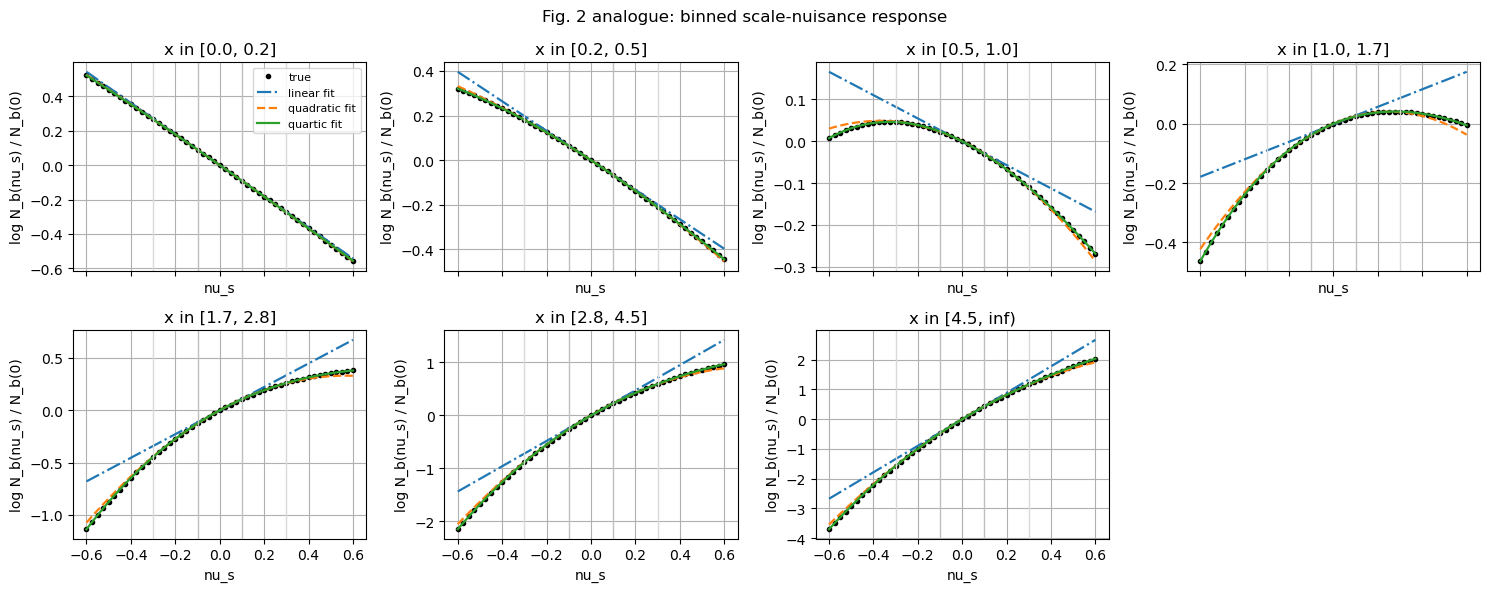

In [64]:
def fit_polynomial_on_window(nu_values, y_values, degree, window):
    mask = np.abs(nu_values) <= window
    coeff = np.polyfit(nu_values[mask], y_values[mask], degree)
    return np.polyval(coeff, nu_values)

nu_scan = np.linspace(-0.6, 0.6, 49)
fig2_bin_edges = np.array([0.0, 0.2, 0.5, 1.0, 1.7, 2.8, 4.5, np.inf])
fig2_bin_labels = [
    "[0.0, 0.2]",
    "[0.2, 0.5]",
    "[0.5, 1.0]",
    "[1.0, 1.7]",
    "[1.7, 2.8]",
    "[2.8, 4.5]",
    "[4.5, inf)",
]

bin_log_ratios = np.vstack([
    paper_exponential_bin_log_ratio(fig2_bin_edges, nu) for nu in nu_scan
])

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
axes = axes.reshape(-1)

for i, ax in enumerate(axes):
    if i >= bin_log_ratios.shape[1]:
        ax.axis("off")
        continue

    y_true = bin_log_ratios[:, i]
    y_linear = fit_polynomial_on_window(nu_scan, y_true, degree=1, window=0.1)
    y_quadratic = fit_polynomial_on_window(nu_scan, y_true, degree=2, window=0.3)
    y_quartic = fit_polynomial_on_window(nu_scan, y_true, degree=4, window=0.6)

    ax.plot(nu_scan, y_true, "o", ms=3, color="black", label="true")
    ax.plot(nu_scan, y_linear, "-.", lw=1.6, label="linear fit")
    ax.plot(nu_scan, y_quadratic, "--", lw=1.6, label="quadratic fit")
    ax.plot(nu_scan, y_quartic, "-", lw=1.6, label="quartic fit")
    ax.axvline(-epsilon_linear, color="0.75", lw=1)
    ax.axvline(+epsilon_linear, color="0.75", lw=1)
    ax.axvline(-epsilon_quadratic, color="0.85", lw=1)
    ax.axvline(+epsilon_quadratic, color="0.85", lw=1)
    ax.set_title(f"x in {fig2_bin_labels[i]}")
    ax.set_xlabel("nu_s")
    ax.set_ylabel("log N_b(nu_s) / N_b(0)")

axes[0].legend(fontsize=8)
fig.suptitle("Fig. 2 analogue: binned scale-nuisance response")
fig.tight_layout();

## Generate Central and Nuisance-Varied Samples

The central sample is drawn at `nu_s = 0` with the NN repo reference statistics. Each varied sample uses the NN repo data statistics, here reused for the `+/-epsilon` nuisance samples needed to learn `log r(x; nu_s)`.

In [65]:
x0 = sample_paper_exponential_nuisance(n_central, 0.0, rng=rng).reshape(-1, 1)
xp_linear = sample_paper_exponential_nuisance(n_varied, +epsilon_linear, rng=rng).reshape(-1, 1)
xm_linear = sample_paper_exponential_nuisance(n_varied, -epsilon_linear, rng=rng).reshape(-1, 1)
xp_quadratic = sample_paper_exponential_nuisance(n_varied, +epsilon_quadratic, rng=rng).reshape(-1, 1)
xm_quadratic = sample_paper_exponential_nuisance(n_varied, -epsilon_quadratic, rng=rng).reshape(-1, 1)

print(x0.shape, xp_linear.shape, xm_linear.shape, xp_quadratic.shape, xm_quadratic.shape)

(50000, 1) (50000, 1) (50000, 1) (50000, 1) (50000, 1)


## Analytic Taylor-Coefficient Check

Before fitting Falkon, check that the closed-form coefficients agree with small finite differences of the analytic log-ratio.

In [66]:
eps_check = 1e-5
x_flat = grid.reshape(-1)

log_r_plus = paper_exponential_log_ratio(x_flat, +eps_check)
log_r_minus = paper_exponential_log_ratio(x_flat, -eps_check)

delta1_true = paper_exponential_delta1(x_flat)
delta2_true = paper_exponential_delta2(x_flat)
delta1_fd = (log_r_plus - log_r_minus) / (2.0 * eps_check)
delta2_fd = (log_r_plus + log_r_minus) / (eps_check**2)

{
    "max_abs_delta1_error": float(np.max(np.abs(delta1_true - delta1_fd))),
    "max_abs_delta2_error": float(np.max(np.abs(delta2_true - delta2_fd))),
}

{'max_abs_delta1_error': 3.930722414224874e-11,
 'max_abs_delta2_error': 4.964422251063638e-07}

## Train the Falkon Morphers

The quadratic morpher trains the `+/-epsilon_linear` pair for `delta1` and the `+/-epsilon_quadratic` pair for `delta2`. With the paper convention, the second coefficient is reconstructed as `(g_+ + g_-) / epsilon_quadratic**2`.

In [67]:
fit_config = dict(ratio_config)
if fit_config["sigma"] is None:
    fit_config["sigma"] = FalkonLogRatioEstimator.estimate_sigma_median(
        np.vstack([x0, xp_linear, xm_linear, xp_quadratic, xm_quadratic]),
        seed=seed,
    )

quadratic_morpher = QuadraticFiniteDifferenceMorpher(
    epsilon_linear=epsilon_linear,
    epsilon_quadratic=epsilon_quadratic,
    config=fit_config,
)
quadratic_morpher.fit(
    x0,
    xp_linear,
    xm_linear,
    xp_quadratic,
    xm_quadratic,
)

linear_morpher = quadratic_morpher.linear_morpher

delta1_falkon = quadratic_morpher.predict_delta1(grid)
delta2_falkon = quadratic_morpher.predict_delta2(grid)

metrics = {
    "sigma": fit_config["sigma"],
    "delta1_rmse": float(np.sqrt(np.mean((delta1_falkon - delta1_true)**2))),
    "delta2_rmse": float(np.sqrt(np.mean((delta2_falkon - delta2_true)**2))),
    "delta1_corr": float(np.corrcoef(delta1_falkon, delta1_true)[0, 1]),
    "delta2_corr": float(np.corrcoef(delta2_falkon, delta2_true)[0, 1]),
    "linear_fit_time_plus": quadratic_morpher.summary_.linear_summary.train_time_plus,
    "linear_fit_time_minus": quadratic_morpher.summary_.linear_summary.train_time_minus,
    "quadratic_fit_time_plus": quadratic_morpher.summary_.quadratic_summary.train_time_plus,
    "quadratic_fit_time_minus": quadratic_morpher.summary_.quadratic_summary.train_time_minus,
}
metrics

Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000
Iteration 0 - penalty 1.000000e-10 - sub-iterations 100000


{'sigma': 0.6998248963790135,
 'delta1_rmse': 0.28522656382501593,
 'delta2_rmse': 0.9877846209031441,
 'delta1_corr': 0.9900713909406952,
 'delta2_corr': 0.8725449109902847,
 'linear_fit_time_plus': 6.642723798751831,
 'linear_fit_time_minus': 17.031091690063477,
 'quadratic_fit_time_plus': 23.74531078338623,
 'quadratic_fit_time_minus': 7.005212783813477}

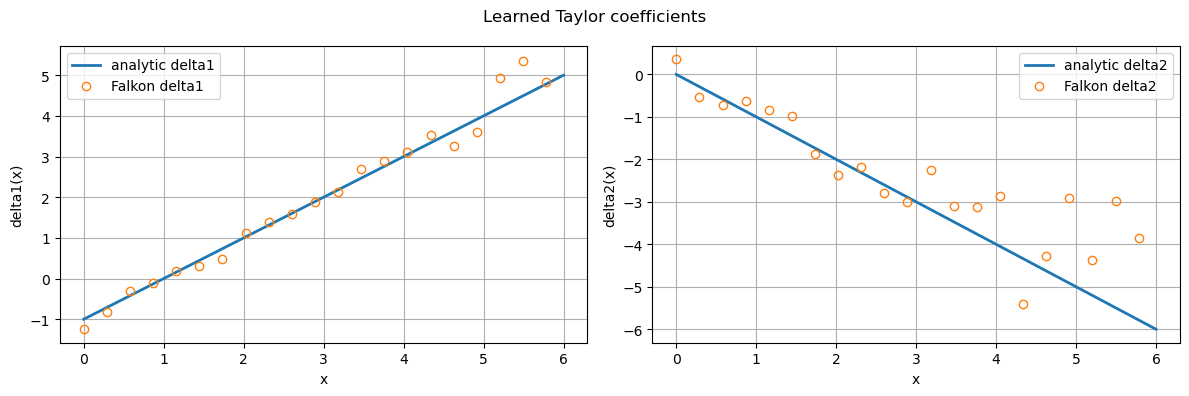

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_flat, delta1_true, label="analytic delta1", lw=2)
axes[0].plot(x_flat, delta1_falkon, "o", fillstyle="none", markevery=12, label="Falkon delta1")
axes[0].set_xlabel("x")
axes[0].set_ylabel("delta1(x)")
axes[0].legend()

axes[1].plot(x_flat, delta2_true, label="analytic delta2", lw=2)
axes[1].plot(x_flat, delta2_falkon, "o", fillstyle="none", markevery=12, label="Falkon delta2")
axes[1].set_xlabel("x")
axes[1].set_ylabel("delta2(x)")
axes[1].legend()

fig.suptitle("Learned Taylor coefficients")
fig.tight_layout();

## Fig. 3 Analogue: Unbinned Log-Ratio Reconstruction

The left panel uses the first-order Falkon reconstruction `nu_s * delta1(x)`. The right panel uses the quadratic reconstruction `nu_s * delta1(x) + 0.5 * nu_s**2 * delta2(x)`. Dashed curves are the analytic log-ratio. Empty markers are binned Falkon predictions, computed as `log(mean(exp(log_r_hat)))` over central/reference events in each bin. Solid curves connect the fourth-order binned approximation from the Fig. 2-style bin fits.

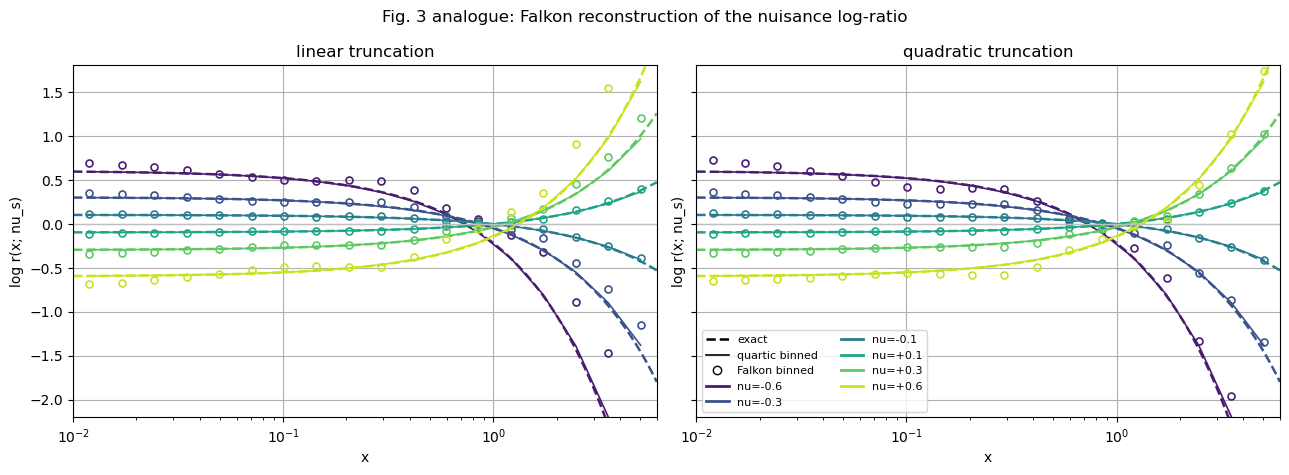

In [74]:
from matplotlib.lines import Line2D


def build_quartic_bin_monitor(bin_edges, nu_values):
    y_by_nu = np.vstack([
        paper_exponential_bin_log_ratio(bin_edges, nu) for nu in nu_values
    ])
    coeffs = []
    for i in range(y_by_nu.shape[1]):
        coeffs.append(np.polyfit(nu_values, y_by_nu[:, i], 4))
    return coeffs


def evaluate_bin_monitor(coeffs, nu):
    return np.asarray([np.polyval(coeff, nu) for coeff in coeffs])


def binned_log_ratio_from_reference(x_ref, log_r_ref, bin_edges):
    x_ref = np.asarray(x_ref).reshape(-1)
    weights = np.exp(np.clip(np.asarray(log_r_ref).reshape(-1), -30.0, 30.0))
    values = []
    for low, high in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (x_ref >= low) & (x_ref < high)
        if np.any(mask):
            values.append(np.log(np.mean(weights[mask])))
        else:
            values.append(np.nan)
    return np.asarray(values)


fig3_nu_values = [-0.6, -0.3, -0.1, 0.1, 0.3, 0.6]
fig3_x_min = 1e-2
fig3_bin_edges = np.geomspace(fig3_x_min, x_plot_max, 19)
fig3_bin_centers = np.sqrt(fig3_bin_edges[:-1] * fig3_bin_edges[1:])
fig3_x_dense = np.geomspace(fig3_x_min, x_plot_max, 250)
fig3_bin_coeffs = build_quartic_bin_monitor(fig3_bin_edges, nu_scan)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(fig3_nu_values)))

x_ref_for_bins = x0.reshape(-1)
delta1_ref_for_bins = quadratic_morpher.predict_delta1(x0)
delta2_ref_for_bins = quadratic_morpher.predict_delta2(x0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for nu, color in zip(fig3_nu_values, colors):
    exact = paper_exponential_log_ratio(fig3_x_dense, nu)
    linear_ref_pred = nu * delta1_ref_for_bins
    quadratic_ref_pred = nu * delta1_ref_for_bins + 0.5 * nu**2 * delta2_ref_for_bins
    linear_binned = binned_log_ratio_from_reference(x_ref_for_bins, linear_ref_pred, fig3_bin_edges)
    quadratic_binned = binned_log_ratio_from_reference(x_ref_for_bins, quadratic_ref_pred, fig3_bin_edges)
    quartic_binned = evaluate_bin_monitor(fig3_bin_coeffs, nu)

    axes[0].plot(fig3_x_dense, exact, "--", color=color, lw=1.8)
    axes[0].plot(fig3_bin_centers, quartic_binned, "-", color=color, lw=1.2)
    axes[0].plot(
        fig3_bin_centers,
        linear_binned,
        "o",
        color=color,
        markerfacecolor="white",
        fillstyle="none",
        ms=5,
        mew=1.2,
    )

    axes[1].plot(fig3_x_dense, exact, "--", color=color, lw=1.8)
    axes[1].plot(fig3_bin_centers, quartic_binned, "-", color=color, lw=1.2)
    axes[1].plot(
        fig3_bin_centers,
        quadratic_binned,
        "o",
        color=color,
        markerfacecolor="white",
        fillstyle="none",
        ms=5,
        mew=1.2,
    )

axes[0].set_title("linear truncation")
axes[1].set_title("quadratic truncation")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlim(fig3_x_min, x_plot_max)
    ax.set_xlabel("x")
    ax.set_ylabel("log r(x; nu_s)")
    ax.set_ylim(-2.2, 1.8)
    ax.axhline(0.0, color="0.75", lw=1)

style_handles = [
    Line2D([0], [0], color="black", ls="--", lw=1.8, label="exact"),
    Line2D([0], [0], color="black", ls="-", lw=1.2, label="quartic binned"),
    Line2D([0], [0], color="black", marker="o", markerfacecolor="white", ls="none", label="Falkon binned"),
]
nu_handles = [
    Line2D([0], [0], color=color, lw=2, label=f"nu={nu:+.1f}")
    for nu, color in zip(fig3_nu_values, colors)
]
axes[1].legend(handles=style_handles + nu_handles, fontsize=8, ncol=2, loc="lower left")
fig.suptitle("Fig. 3 analogue: Falkon reconstruction of the nuisance log-ratio")
fig.tight_layout();

## Quadratic Cache Check

The profiled statistic only needs repeated evaluations on fixed reference/data events. Cache the learned `delta1` and `delta2` arrays instead of serializing Falkon models.

In [ ]:
x_data_like = sample_paper_exponential_nuisance(250, nu_data, rng=rng).reshape(-1, 1)

cache = quadratic_morpher.build_cache(
    X_ref=x0[:500],
    X_data=x_data_like,
    metadata={"toy": "paper_exponential_scale_1d"},
)

cache_path = Path("/tmp") / "systematics_1d_ratio_cache.npz"
cache.save_npz(cache_path)
loaded = QuadraticLogRMorphingCache.load_npz(cache_path)

assert np.allclose(cache.delta1_ref, loaded.delta1_ref)
assert np.allclose(cache.delta2_ref, loaded.delta2_ref)
assert np.allclose(cache.delta1_data, loaded.delta1_data)
assert np.allclose(cache.delta2_data, loaded.delta2_data)
assert np.allclose(cache.log_r_ref(nu_data), loaded.log_r_ref(nu_data))

print("cache saved to", cache_path)
print("delta1_ref shape:", loaded.delta1_ref.shape)
print("delta2_ref shape:", loaded.delta2_ref.shape)
print("delta1_data shape:", loaded.delta1_data.shape)
print("delta2_data shape:", loaded.delta2_data.shape)
print("mean r_ref(nu_data):", float(np.mean(loaded.r_ref(nu_data))))